In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel(r"C:\Users\user\Desktop\MAGISTERKA\dane_202412.xlsx")
df['rok_miesiac'] = pd.to_datetime(df['rok_miesiac'], format='%Y%m')
df.set_index('rok_miesiac', inplace=True)
df = df[df.index>='2001']
df.tail()

,stopa_bezrobocia
rok_miesiac,
2024-08-01,5.0
2024-09-01,5.0
2024-10-01,4.9
2024-11-01,5.0
2024-12-01,5.1


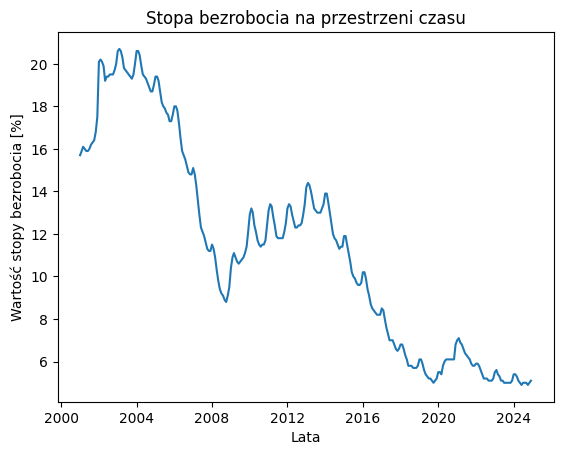

In [3]:
sns.lineplot(data=df, x=df.index, y='stopa_bezrobocia')
plt.title('Stopa bezrobocia na przestrzeni czasu')
plt.xlabel('Lata')
plt.ylabel('Wartość stopy bezrobocia [%]')
plt.show();

In [4]:
df.stopa_bezrobocia.describe()

count    288.000000
mean      11.359028
std        4.926348
min        4.900000
25%        6.275000
50%       11.400000
75%       14.800000
max       20.700000
Name: stopa_bezrobocia, dtype: float64

Badanie stacjonarności z użycie testu ADF (Augmented Dickey-Fuller test)

In [5]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(df, column):
    result = adfuller(df[column])
    if result[1] > 0.05:
        print(f"Odrzucamy H0 na rzecz H1. Szereg niestacjonarny.")
    else:
        print(f"Brak podstaw do odrzucenia H0. Szereg stacjonarny.")

    print('\nParametry testu:')
    return result

In [6]:
test_stationarity(df, 'stopa_bezrobocia')

Odrzucamy H0 na rzecz H1. Szereg niestacjonarny.

Parametry testu:


(np.float64(-2.1002114018329574),
 np.float64(0.24442960425885613),
 14,
 273,
 {'1%': np.float64(-3.45453261164607),
  '5%': np.float64(-2.8721859575020017),
  '10%': np.float64(-2.572442854861866)},
 np.float64(-288.9662278425492))

Liczymy przyrosty i badamy ich stacjonarność

In [7]:
df['stopa_bezrobocia_diff'] = df['stopa_bezrobocia'].diff()
# df = df.dropna()
df.head()

,stopa_bezrobocia,stopa_bezrobocia_diff
rok_miesiac,,
2001-01-01,15.7,NaN
2001-02-01,15.9,0.2
2001-03-01,16.1,0.2
2001-04-01,16.0,-0.1
2001-05-01,15.9,-0.1


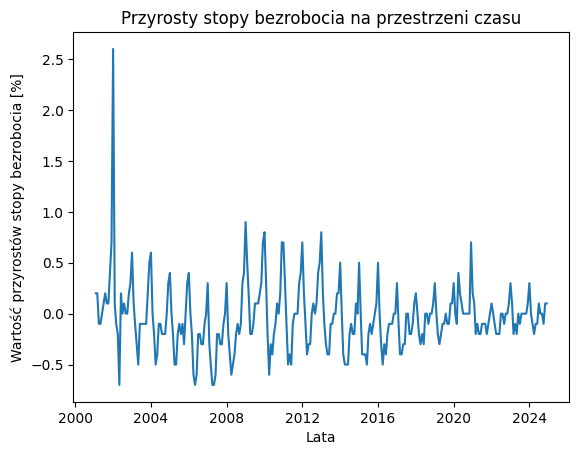

In [8]:
sns.lineplot(data=df.dropna(), x=df.dropna().index, y='stopa_bezrobocia_diff')
plt.title('Przyrosty stopy bezrobocia na przestrzeni czasu')
plt.xlabel('Lata')
plt.ylabel('Wartość przyrostów stopy bezrobocia [%]')
plt.show();

In [9]:
test_stationarity(df.dropna(), 'stopa_bezrobocia_diff')

Brak podstaw do odrzucenia H0. Szereg stacjonarny.

Parametry testu:


(np.float64(-3.425114389407471),
 np.float64(0.010131943063992867),
 14,
 272,
 {'1%': np.float64(-3.4546223782586534),
  '5%': np.float64(-2.8722253212300277),
  '10%': np.float64(-2.5724638500216264)},
 np.float64(-295.07371263349035))

Sprawdźmy jeszcze logarytmy stóp zwrotu.

In [10]:
df.loc[:, 'stopa_bezrobocia_log'] = np.log(df['stopa_bezrobocia'])
df.head()

,stopa_bezrobocia,stopa_bezrobocia_diff,stopa_bezrobocia_log
rok_miesiac,,,
2001-01-01,15.7,NaN,2.753661
2001-02-01,15.9,0.2,2.766319
2001-03-01,16.1,0.2,2.778819
2001-04-01,16.0,-0.1,2.772589
2001-05-01,15.9,-0.1,2.766319


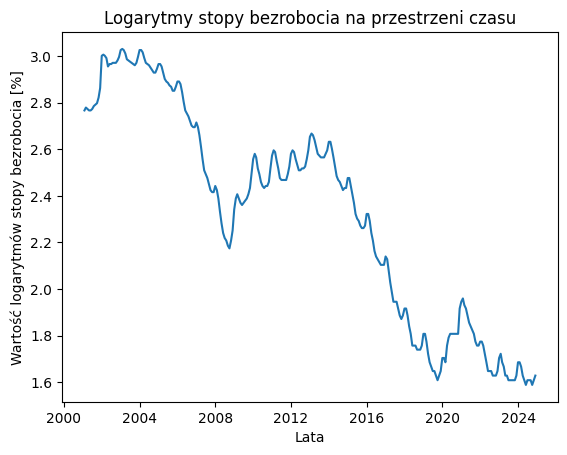

In [11]:
sns.lineplot(data=df.dropna(), x=df.dropna().index, y='stopa_bezrobocia_log')
plt.title('Logarytmy stopy bezrobocia na przestrzeni czasu')
plt.xlabel('Lata')
plt.ylabel('Wartość logarytmów stopy bezrobocia [%]')
plt.show();

In [12]:
test_stationarity(df, 'stopa_bezrobocia_log')

Odrzucamy H0 na rzecz H1. Szereg niestacjonarny.

Parametry testu:


(np.float64(-1.1499339309477679),
 np.float64(0.6947539119815398),
 14,
 273,
 {'1%': np.float64(-3.45453261164607),
  '5%': np.float64(-2.8721859575020017),
  '10%': np.float64(-2.572442854861866)},
 np.float64(-1461.9824445829345))

Sprawdzamy pierwiastek stopy 

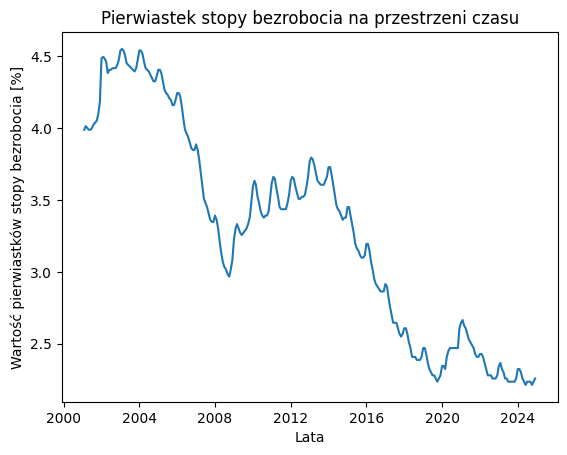

Odrzucamy H0 na rzecz H1. Szereg niestacjonarny.

Parametry testu:


(np.float64(-1.5851942582118075),
 np.float64(0.4910265346411775),
 14,
 273,
 {'1%': np.float64(-3.45453261164607),
  '5%': np.float64(-2.8721859575020017),
  '10%': np.float64(-2.572442854861866)},
 np.float64(-1273.139626912718))

In [13]:
df.loc[:, 'stopa_bezrobocia_sqrt'] = np.sqrt(df['stopa_bezrobocia'])
sns.lineplot(data=df.dropna(), x=df.dropna().index, y='stopa_bezrobocia_sqrt')
plt.title('Pierwiastek stopy bezrobocia na przestrzeni czasu')
plt.xlabel('Lata')
plt.ylabel('Wartość pierwiastków stopy bezrobocia [%]')
plt.show();
test_stationarity(df, 'stopa_bezrobocia_sqrt')

Wszystkie transformacje ewindentnie pokazują, że właściwym przekształceniem jest policzenie przyrostów stopy bezrobocia, a szereg taki jest stacjonarny, a co za tym idzie jest on zdany do modelowania.

In [14]:
df = df.drop(columns=['stopa_bezrobocia_log','stopa_bezrobocia_sqrt']).dropna()
df.head(2)

,stopa_bezrobocia,stopa_bezrobocia_diff
rok_miesiac,,
2001-02-01,15.9,0.2
2001-03-01,16.1,0.2


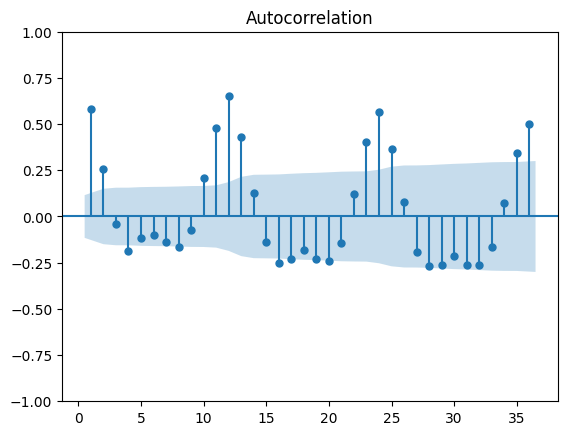

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df.stopa_bezrobocia_diff, lags=36, alpha= 0.05, zero=False)
plt.show();

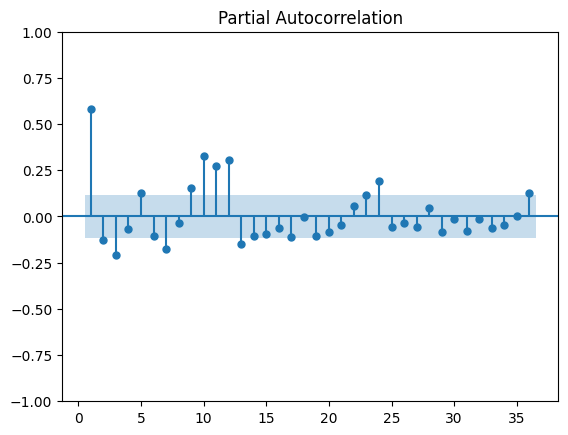

In [16]:
plot_pacf(df.stopa_bezrobocia_diff, lags=36, alpha=0.05, zero=False)
plt.show();

Liczymy pierwszy model AR(1)

C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


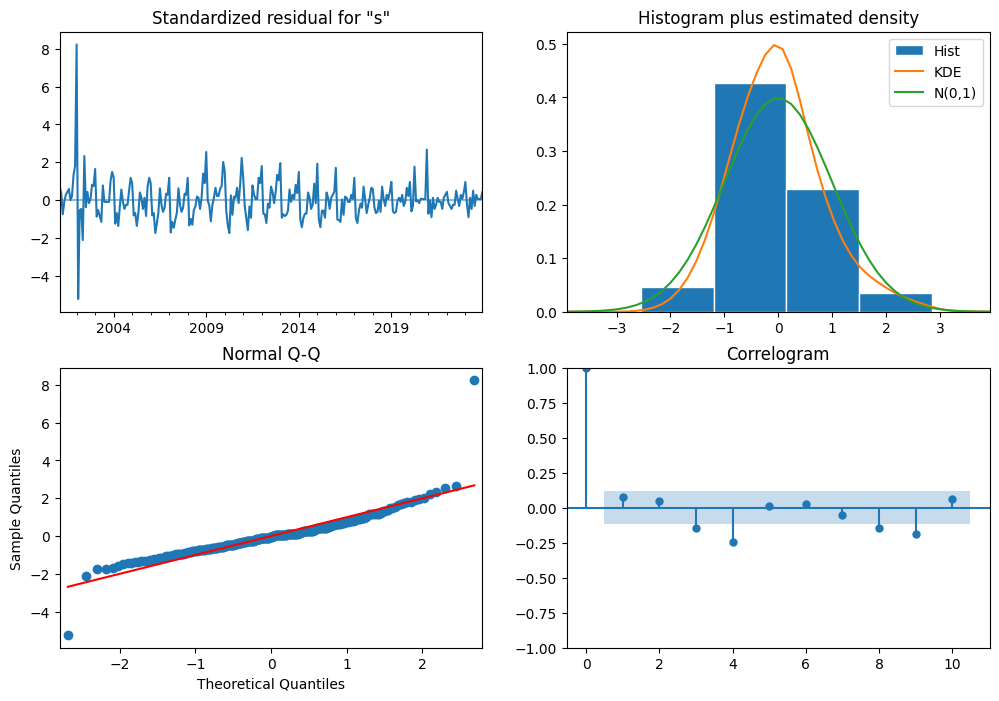

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                 
=================================================================================
Dep. Variable:     stopa_bezrobocia_diff   No. Observations:                  275
Model:                    ARIMA(1, 0, 0)   Log Likelihood                 -28.116
Date:                   Wed, 05 Feb 2025   AIC                             62.231
Time:                           18:20:08   BIC                             73.082
Sample:                       02-01-2001   HQIC                            66.586
                            - 12-01-2023                                         
Covariance Type:                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0366      0.050     -0.736      0.462      -0.134       0.061
ar.L1          0.5841      0.020     28.976      0.000       0.545       0.624
sigma2         0.0717      0.002     33.562      0.000       0.068       0.076
===================================================================================
Ljung-Box (L1) (Q):                   1.54   Jarque-Bera (JB):              3863.87
Prob(Q):                              0.21   Prob(JB):                         0.00
Heteroskedasticity (H):               0.18   Skew:                             1.75
Prob(H) (two-sided):                  0.00   Kurtosis:                        21.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df[df.index<='2023-12-31'][['stopa_bezrobocia_diff']], order=(1,0,0))
result = model.fit()
fig = result.plot_diagnostics(figsize=(12, 8))
plt.show();
result.summary()

Prob(Q) > 0.05, czyli reszty nie są ze sobą skorelowane, jednak nie rozkładają się one normalnie <=> Prob(JB) < 0.05.

In [18]:
from scipy.stats import shapiro
stat, p_value = shapiro(result.resid)
print(f"Shapiro-Wilk Test: stat={stat}, p={p_value}")

Shapiro-Wilk Test: stat=0.85161167913626, p=1.478012177553652e-15


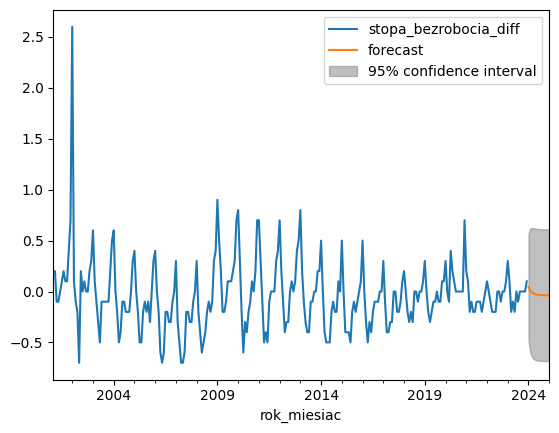

In [19]:
from statsmodels.graphics.tsaplots import plot_predict
fig, ax = plt.subplots()
df[df.index<='2023-12-31'][['stopa_bezrobocia_diff']].plot(ax = ax)
plot_predict(result, start = '2024-01-01', end = '2024-12-31', alpha = 0.05, ax=ax)
plt.show()

In [20]:
forecast = result.get_forecast(12)
# forecast.predicted_mean
forecast.summary_frame()

stopa_bezrobocia_diff,mean,mean_se,mean_ci_lower,mean_ci_upper
2024-01-01,0.043169,0.267810,-0.481729,0.568067
2024-02-01,0.009975,0.310148,-0.597904,0.617854
2024-03-01,-0.009414,0.323326,-0.643122,0.624294
2024-04-01,-0.020739,0.327701,-0.663022,0.621544
2024-05-01,-0.027354,0.329181,-0.672536,0.617828
2024-06-01,-0.031218,0.329684,-0.677386,0.614951
2024-07-01,-0.033474,0.329855,-0.679979,0.613030
2024-08-01,-0.034793,0.329914,-0.681412,0.611826
2024-09-01,-0.035563,0.329934,-0.682221,0.611095
2024-10-01,-0.036012,0.329940,-0.682684,0.610659


In [21]:
from sklearn.metrics import mean_squared_error

ar_mse = mean_squared_error(df[df.index>'2023-12-31']['stopa_bezrobocia_diff'], forecast.summary_frame()['mean'])
print(f'MSE dla AR(1): {ar_mse}')
print(f'RMSE dla AR(1): {np.sqrt(ar_mse)}')
print(f'AIC: {result.aic}')
print(f'BIC: {result.bic}')

MSE dla AR(1): 0.01483157676726537
RMSE dla AR(1): 0.12178496117035703
AIC: 62.2313476916515
BIC: 73.08166098465122


Podejście z wykorzystaniem xgboost

In [22]:
df_raw = df

In [23]:
df_xg = df[['stopa_bezrobocia_diff']].rename(columns={'stopa_bezrobocia_diff': 'target'})
for i in range(5):
    df_xg[f'value_lag-{i+1}'] = df_xg['target'].shift(i+1)

df_xg = df_xg.dropna()
df_xg.head()

,target,value_lag-1,value_lag-2,value_lag-3,value_lag-4,value_lag-5
rok_miesiac,,,,,,
2001-07-01,0.1,0.0,-0.1,-0.1,0.2,0.2
2001-08-01,0.2,0.1,0.0,-0.1,-0.1,0.2
2001-09-01,0.1,0.2,0.1,0.0,-0.1,-0.1
2001-10-01,0.1,0.1,0.2,0.1,0.0,-0.1
2001-11-01,0.4,0.1,0.1,0.2,0.1,0.0


In [24]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

testing_periods = 12

X_train, X_test, y_train, y_test = df_xg.drop(columns=['target'])[:-testing_periods], df_xg.drop(columns=['target'])[-testing_periods:], df_xg[['target']][:-testing_periods], df_xg[['target']][-testing_periods:]

In [25]:
print(f'X_train.shape: {X_train.shape}')
print(f'X_test.shape: {X_test.shape}')

X_train.shape: (270, 5)
X_test.shape: (12, 5)


In [28]:
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist = {
    'n_estimators': [50, 100],         
    'max_depth': [3, 4, 5],           
    'learning_rate': [0.01, 0.05],  
    'subsample': [0.8, 1.0],               
    'colsample_bytree': [0.8, 1.0],        
    'gamma': [0, 0.1],             
    'reg_alpha': [0, 0.1],              
    'reg_lambda': [1,  2]  
}


random_search = RandomizedSearchCV(
    estimator=model, 
    param_distributions=param_dist, 
    n_iter=50, 
    scoring='neg_mean_squared_error', 
    cv=5, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Najlepsze parametry: ", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"MSE najlepszego modelu: {mse}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Najlepsze parametry:  {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
MSE najlepszego modelu: 0.0207635772289491


In [29]:
n = len(y_test)
k = best_model.get_booster().num_boosted_rounds() + X_train.shape[1] 

aic = n * np.log(mse) + 2 * k
bic = n * np.log(mse) + np.log(n) * k

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')
print(f'AIC: {aic}')
print(f'BIC: {bic}')

Mean Squared Error: 0.0207635772289491
Root Mean Squared Error: 0.14409572245194893
AIC: 163.50534093605367
BIC: 214.42053916379373


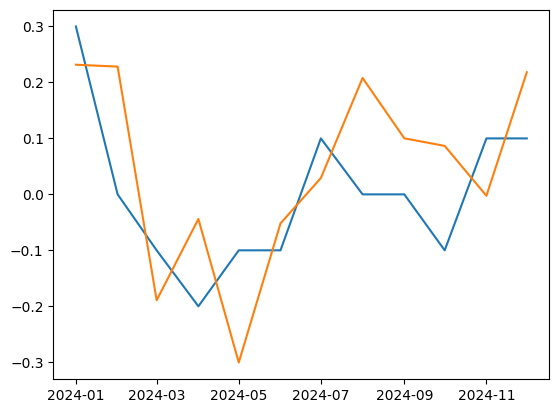

In [30]:
fig, ax = plt.subplots()
ax.plot(y_test.index, y_test['target'])
ax.plot(y_test.index, y_pred)

Model ARIMA(1,0,1)

C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


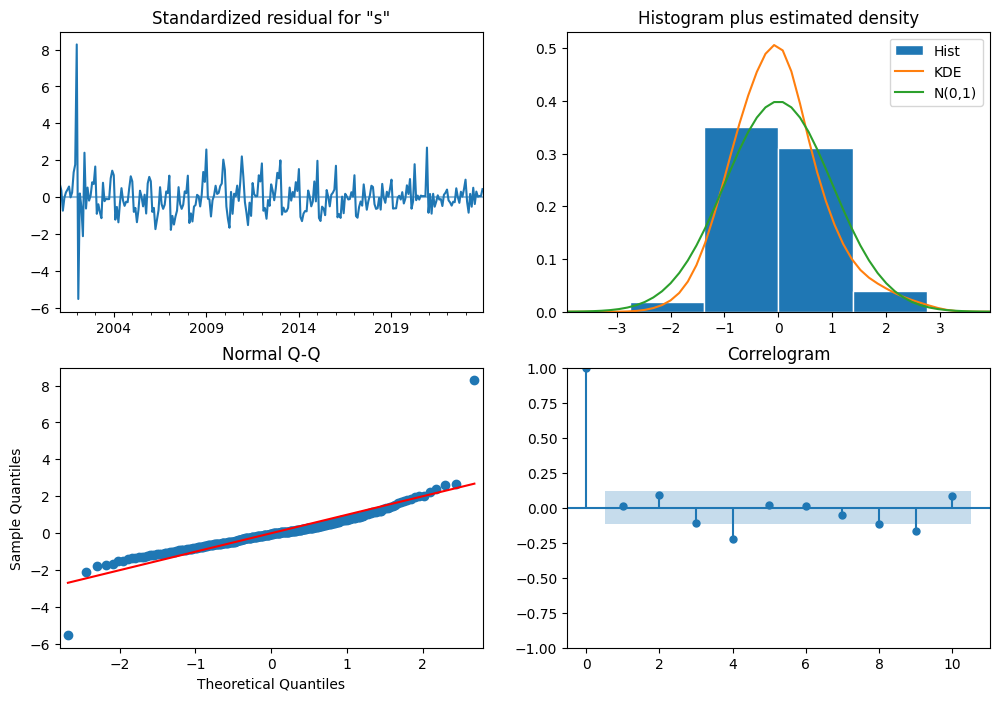

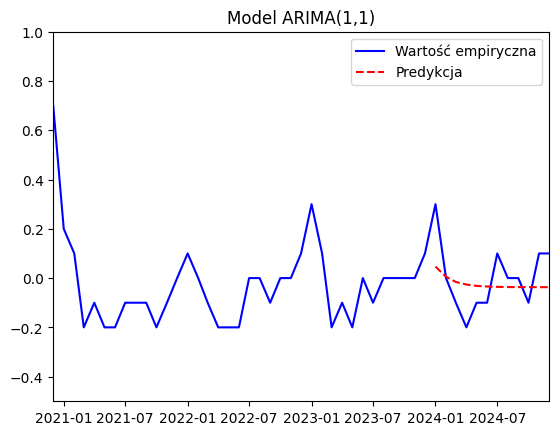

MSE dla modelu ARIMA(1,1): 0.01441591291132661
RMSE dla modelu ARIMA(1,1): 0.1200662854898352
AIC dla modelu ARIMA(1,1): 61.6917913152082
BIC dla modelu ARIMA(1,1): 76.1588757058745


In [95]:
model = ARIMA(df[df.index<='2023-12-31'][['stopa_bezrobocia_diff']], order=(1,0,1))
result_arima = model.fit()
fig = result_arima.plot_diagnostics(figsize=(12, 8))
plt.show();
# result.summary()

forecast_steps = 12 
forecast = result_arima.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()
# print(forecast_df)

fig, ax = plt.subplots()
plt.plot(df[['stopa_bezrobocia_diff']], label='Wartość empiryczna', color='b')
plt.plot(forecast.summary_frame()['mean'], label='Predykcja', color='r', linestyle='--')
plt.title('Model ARIMA(1,1)')
plt.xlim(df.index[-1] - pd.DateOffset(years=4), df.index[-1])
plt.ylim(-0.5, 1)
plt.legend()
plt.show();

y_true = df['stopa_bezrobocia_diff'][-forecast_steps:]
y_pred = forecast_df['mean']
mse_arima = mean_squared_error(y_true, y_pred[:len(y_true)])
print(f"MSE dla modelu ARIMA(1,1): {mse_arima}")
print(f"RMSE dla modelu ARIMA(1,1): {np.sqrt(mse_arima)}")
print(f"AIC dla modelu ARIMA(1,1): {result_arima.aic}")
print(f"BIC dla modelu ARIMA(1,1): {result_arima.bic}")

MODEL AR(1)

C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


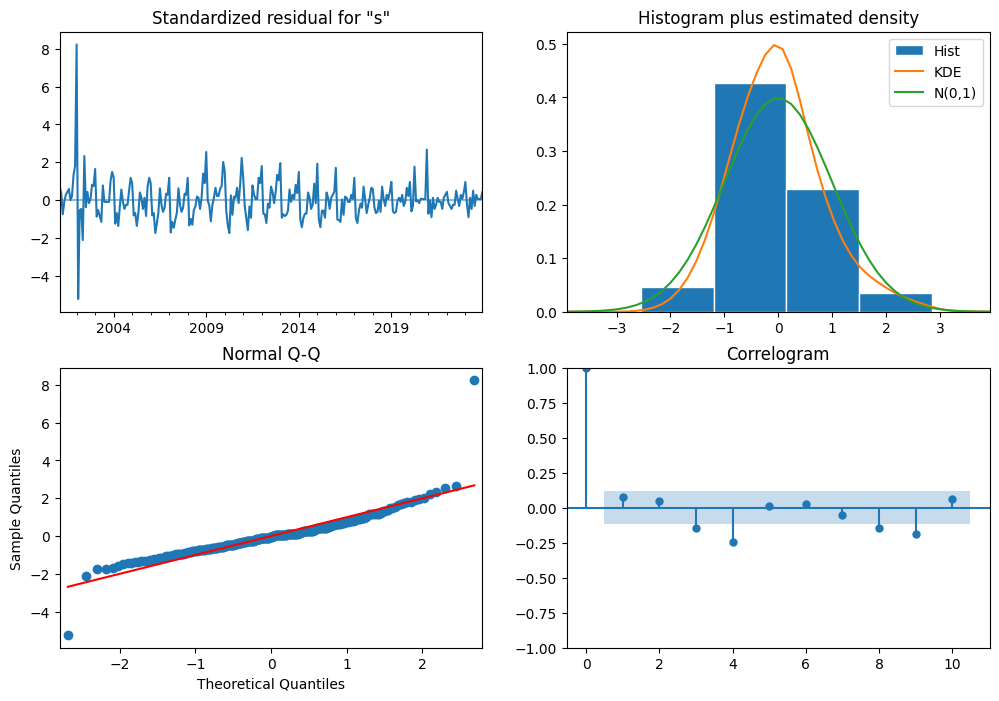

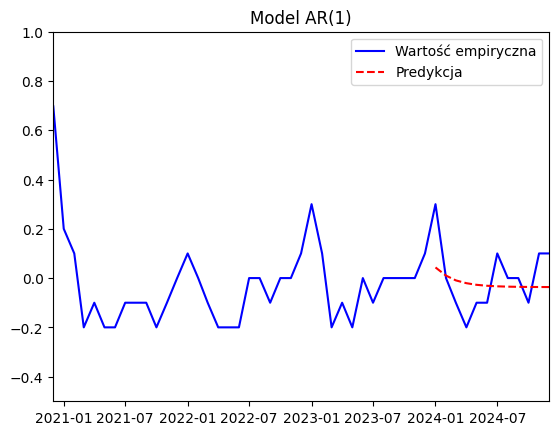

MSE dla modelu AR(1): 0.01483157676726537
RMSE dla modelu AR(1): 0.12178496117035703
AIC dla modelu AR(1): 62.2313476916515
BIC dla modelu AR(1): 73.08166098465122


In [94]:
model = ARIMA(df[df.index<='2023-12-31'][['stopa_bezrobocia_diff']], order=(1,0,0))
result_ar = model.fit()
fig = result_ar.plot_diagnostics(figsize=(12, 8))
plt.show();
# result.summary()

forecast_steps = 12 
forecast = result_ar.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()
# print(forecast_df)

fig, ax = plt.subplots()
plt.plot(df[['stopa_bezrobocia_diff']], label='Wartość empiryczna', color='b')
plt.plot(forecast.summary_frame()['mean'], label='Predykcja', color='r', linestyle='--')
plt.title('Model AR(1)')
plt.xlim(df.index[-1] - pd.DateOffset(years=4), df.index[-1])
plt.ylim(-0.5, 1)
plt.legend()
plt.show();

y_true = df['stopa_bezrobocia_diff'][-forecast_steps:]
y_pred = forecast_df['mean']
mse_ar = mean_squared_error(y_true, y_pred[:len(y_true)])
print(f"MSE dla modelu AR(1): {mse_ar}")
print(f"RMSE dla modelu AR(1): {np.sqrt(mse_ar)}")
print(f"AIC dla modelu AR(1): {result_ar.aic}")
print(f"BIC dla modelu AR(1): {result_ar.bic}")

MODEL SARIMA

C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:               stopa_bezrobocia_diff   No. Observations:                  275
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood                  73.378
Date:                             Wed, 05 Feb 2025   AIC                           -138.756
Time:                                     19:04:27   BIC                           -124.467
Sample:                                 02-01-2001   HQIC                          -133.014
                                      - 12-01-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9054      0.054     16.703      0.000       0.799       1.012
ma.L1         -0.6279      

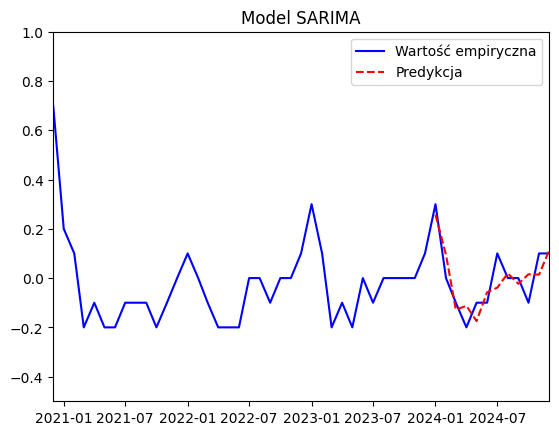

MSE dla modelu SARIMA: 0.005629785590879582
RMSE dla modelu SARIMA: 0.07503189715634
AIC dla modelu SARIMA: -138.7561150532513
BIC dla modelu SARIMA: -124.46749892454025


In [109]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df[df.index<='2023-12-31'][['stopa_bezrobocia_diff']], order=(1, 0, 1), seasonal_order=(1, 1,0, 12))
result_sar = model.fit()

print(result_sar.summary())

forecast_steps = 12
forecast = result_sar.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

fig, ax = plt.subplots()
plt.plot(df[['stopa_bezrobocia_diff']], label='Wartość empiryczna', color='b')
plt.plot(forecast.summary_frame()['mean'], label='Predykcja', color='r', linestyle='--')
plt.title('Model SARIMA')
plt.xlim(df.index[-1] - pd.DateOffset(years=4), df.index[-1])
plt.ylim(-0.5, 1)
plt.legend()
plt.show()

y_true = df['stopa_bezrobocia_diff'][-forecast_steps:]  # Prawdziwe wartości na końcu
y_pred = forecast_df['mean']
mse_sar = mean_squared_error(y_true, y_pred[:len(y_true)])
print(f"MSE dla modelu SARIMA: {mse_sar}")
print(f"RMSE dla modelu SARIMA: {np.sqrt(mse_sar)}")
print(f"AIC dla modelu SARIMA: {result_sar.aic}")
print(f"BIC dla modelu SARIMA: {result_sar.bic}")

Model Holt-Wintersa

C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


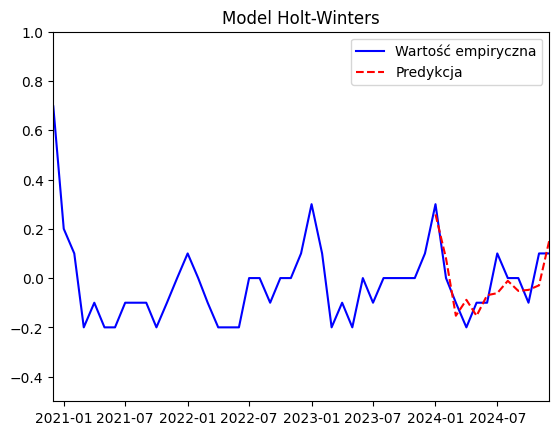

MSE dla modelu HW: 0.006502230259329639
RMSE dla modelu HW: 0.08063640777793638
AIC dla modelu HW: -925.3107725164024
BIC dla modelu HW: -867.4424349537372


In [110]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(df[df.index<='2023-12-31'][['stopa_bezrobocia_diff']], trend="add", seasonal="add", seasonal_periods=12)
result_hw = model.fit()
forecast = result_hw.forecast(steps=12)

fig, ax = plt.subplots()
plt.plot(df[['stopa_bezrobocia_diff']], label='Wartość empiryczna', color='b')
plt.plot(forecast, label='Predykcja', color='r', linestyle='--')
plt.title('Model Holt-Winters')
plt.xlim(df.index[-1] - pd.DateOffset(years=4), df.index[-1])
plt.ylim(-0.5, 1)
plt.legend()
plt.show()


y_true = df['stopa_bezrobocia_diff'][-12:]
y_pred = forecast
mse_hw = mean_squared_error(y_true, y_pred[:len(y_true)])
print(f"MSE dla modelu HW: {mse_hw}")
print(f"RMSE dla modelu HW: {np.sqrt(mse_hw)}")
print(f"AIC dla modelu HW: {result_hw.aic}")
print(f"BIC dla modelu HW: {result_hw.bic}")

In [113]:
pd.DataFrame({'Model':['AR(1)', 'ARIMA(1,0,1)', 'SARIMA(1,0,1)(1,1,0,12)', 'Holt-Winters'], 'MSE':[mse_ar, mse_arima, mse_sar, mse_hw], 'RMSE':[np.sqrt(mse_ar), np.sqrt(mse_arima), np.sqrt(mse_sar), np.sqrt(mse_hw)],
             'AIC':[result_ar.aic, result_arima.aic, result_sar.aic, result_hw.aic], 'BIC':[result_ar.bic, result_arima.bic, result_sar.bic, result_hw.bic]}).set_index('Model')

,MSE,RMSE,AIC,BIC
Model,,,,
AR(1),0.014832,0.121785,62.231348,73.081661
"ARIMA(1,0,1)",0.014416,0.120066,61.691791,76.158876
"SARIMA(1,0,1)(1,1,0,12)",0.005630,0.075032,-138.756115,-124.467499
Holt-Winters,0.006502,0.080636,-925.310773,-867.442435
